# 10. Multi-Step Temporal Spectrum Occupancy Prediction using Deep Learning

This notebook implements multi-step temporal spectrum occupancy prediction models based on the paper:
"Multi Step Temporal Spectrum Occupancy Prediction using Deep Learning"

**Models implemented:**
- Vanilla LSTM
- Encoder-Decoder LSTM
- 1D CNN
- Baseline (Naive predictor)

**Metrics:** MAE, RMSE, MASE

**Data:** Reads from `work_dir/final/training/` and `work_dir/final/testing/` directories.
Time series data with x-axis = frequency, y-axis = hour of day, value = air time utilization (%).

Install dependencies from the repo root: `pip install -r requirements.txt`

In [2]:
# Dependencies (tensorflow, scikit-learn, etc.) are in requirements.txt — install from repo root.

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Deep learning libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')

TensorFlow version: 2.18.1
Keras version: 3.13.2


**GPU:** Use kernel **Python 3.11 (cablelabs-3 .venv)** (Kernel → Change kernel) so this notebook runs in the project's venv where tensorflow-metal is installed.

In [4]:
# Use all available GPU and CPU (use kernel "Python 3.11 (cablelabs-3 .venv)" for GPU)
import os

# GPU setup (threading not set — TF already initialized by import in previous cell)
# 1) Prefer GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus, 'GPU')
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f'GPU enabled: {len(gpus)} device(s) — {[g.name for g in gpus]}')
    except RuntimeError as e:
        print('GPU config:', e)
else:
    print('No GPU found. Change kernel to "Python 3.11 (cablelabs-3 .venv)" (Kernel → Change kernel), then re-run from the top.')

# 3) Warm up GPU so it is used from the first op
if gpus:
    with tf.device('/GPU:0'):
        _ = tf.constant(1)
    print('GPU ready for training.')

# 4) Flag for training: larger batch size when GPU available to keep it busy
USE_GPU = len(gpus) > 0

GPU enabled: 1 device(s) — ['/physical_device:GPU:0']
CPU threads: intra=10, inter=10
GPU ready for training.


2026-02-09 20:19:28.188814: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-02-09 20:19:28.188882: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2026-02-09 20:19:28.188889: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 12.48 GB
I0000 00:00:1770686368.189238 41376535 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1770686368.189591 41376535 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Predict next day

- **Training:** 6 days of data. We use the **last 3 days (72 hours)** as input and the **next 24 hours (next day)** as target. Sliding this over the 6 days gives many training samples per frequency.
- **Testing:** 3 days of data. We form **one sample per test day**: input = previous 72 hours (last 3 train days for day 1; mix of train + prior test days for days 2–3), target = that test day’s 24 hours. So we get 3 test samples per frequency — true “next day” prediction.
- **Parameters:** `LOOKBACK = 72` (last 3 days), `FORECAST_HORIZON = 24` (next day).

In [5]:
# Path to final data
work_dir = Path("work_dir")
if not work_dir.exists():
    work_dir = Path("../work_dir")
final_dir = work_dir / "final"
if not final_dir.exists():
    raise FileNotFoundError('Final dir not found: ' + str(final_dir))

# Discover classes (bands) from training directory
training_dir = final_dir / "training"
testing_dir = final_dir / "testing"

if not training_dir.exists() or not testing_dir.exists():
    raise FileNotFoundError('Training or testing directory not found')

classes_found = []
for band_dir in sorted(training_dir.iterdir()):
    if band_dir.is_dir():
        classes_found.append(band_dir.name)

class_options = sorted(set(classes_found))
print(f'Found {len(class_options)} classes (bands): {class_options}')

Found 6 classes (bands): ['195MHz', '2441MHz', '3765MHz', '539MHz', '5500MHz', '915MHz']


## Data Loading and Preparation

In [6]:
def load_data_for_band(band_name: str, split: str = "training"):
    """Load all parquet files for a given band and split."""
    split_dir = final_dir / split / band_name
    if not split_dir.exists():
        return pd.DataFrame()
    
    dfs = []
    for p in sorted(split_dir.glob("final_*.parquet")):
        try:
            df = pd.read_parquet(p)
            dfs.append(df)
        except Exception as e:
            print(f'Error loading {p}: {e}')
            continue
    
    if not dfs:
        return pd.DataFrame()
    
    combined = pd.concat(dfs, ignore_index=True)
    return combined


def prepare_sequences(df: pd.DataFrame, lookback: int = 10, forecast_horizon: int = 1):
    """
    Prepare sequences for time series prediction.
    
    For each frequency bin, create sequences where:
    - Input: L consecutive hours (lookback)
    - Output: T future hours (forecast_horizon)
    
    Args:
        df: DataFrame with columns [date, hour, band, freq_center_ghz, threshold_dbm, au_pct]
        lookback: Number of past hours to use as input (L)
        forecast_horizon: Number of future hours to predict (T)
    
    Returns:
        X: Input sequences (n_samples, lookback, n_features)
        y: Target sequences (n_samples, forecast_horizon)
    """
    # Get unique frequencies and threshold
    freqs = sorted(df["freq_center_ghz"].unique())
    thresholds = sorted(df["threshold_dbm"].unique())
    
    if len(thresholds) > 1:
        # Use first threshold if multiple exist
        df = df[df["threshold_dbm"] == thresholds[0]].copy()
    
    X_list, y_list = [], []
    
    # For each frequency bin, create sequences
    for freq in freqs:
        freq_data = df[df["freq_center_ghz"] == freq].copy()
        freq_data = freq_data.sort_values(["date", "hour"])
        
        # Extract au_pct values as time series
        values = freq_data["au_pct"].values
        
        # Create sliding windows
        for i in range(len(values) - lookback - forecast_horizon + 1):
            X_list.append(values[i:i+lookback])
            y_list.append(values[i+lookback:i+lookback+forecast_horizon])
    
    if not X_list:
        return np.array([]), np.array([])
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    # Reshape for models: (n_samples, lookback, 1) for univariate
    X = X.reshape((X.shape[0], X.shape[1], 1))
    
    return X, y


def prepare_next_day_sequences(train_df: pd.DataFrame, test_df: pd.DataFrame,
                                lookback: int = 72, forecast_horizon: int = 24):
    """
    Next-day prediction: one sample per test day.
    - Train: sliding window (input lookback h -> target next 24h).
    - Test: 3 samples — input = previous lookback h (from train and/or prior test days), target = that day's 24h.
    """
    freqs = sorted(train_df["freq_center_ghz"].unique())
    thresholds = sorted(train_df["threshold_dbm"].unique())
    if len(thresholds) > 1:
        train_df = train_df[train_df["threshold_dbm"] == thresholds[0]].copy()
        test_df = test_df[test_df["threshold_dbm"] == thresholds[0]].copy()

    X_train_list, y_train_list = [], []
    X_test_list, y_test_list = [], []

    for freq in freqs:
        tr = train_df[train_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values
        te = test_df[test_df["freq_center_ghz"] == freq].sort_values(["date", "hour"])["au_pct"].values

        for i in range(len(tr) - lookback - forecast_horizon + 1):
            X_train_list.append(tr[i:i+lookback])
            y_train_list.append(tr[i+lookback:i+lookback+forecast_horizon])

        n_test_days = len(te) // forecast_horizon
        for d in range(n_test_days):
            if d == 0:
                input_slice = tr[-lookback:] if len(tr) >= lookback else np.concatenate([np.zeros(lookback - len(tr)), tr])
            else:
                hours_from_train = max(0, lookback - d * forecast_horizon)
                if hours_from_train > 0:
                    input_slice = np.concatenate([tr[-hours_from_train:], te[0:d*forecast_horizon]])
                else:
                    input_slice = te[d*forecast_horizon - lookback:d*forecast_horizon]
            target_slice = te[d*forecast_horizon:(d+1)*forecast_horizon]
            if len(input_slice) == lookback and len(target_slice) == forecast_horizon:
                X_test_list.append(input_slice)
                y_test_list.append(target_slice)

    if not X_train_list or not X_test_list:
        return np.array([]), np.array([]), np.array([]), np.array([])
    X_train = np.array(X_train_list).reshape(-1, lookback, 1)
    y_train = np.array(y_train_list)
    X_test = np.array(X_test_list).reshape(-1, lookback, 1)
    y_test = np.array(y_test_list)
    return X_train, y_train, X_test, y_test

In [7]:
# Load training and testing data for all bands
# Next-day prediction: use last 3 days (72h) as input to predict next day (24h)
LOOKBACK = 72  # last 3 days (hours)
FORECAST_HORIZON = 24  # next day (hours)

train_data_by_band = {}
test_data_by_band = {}

for band in class_options:
    train_df = load_data_for_band(band, "training")
    test_df = load_data_for_band(band, "testing")
    
    if not train_df.empty and not test_df.empty:
        train_data_by_band[band] = train_df
        test_data_by_band[band] = test_df
        print(f'Band {band}: Training={len(train_df)} rows, Testing={len(test_df)} rows')

print(f'\nLoaded data for {len(train_data_by_band)} bands')

Band 195MHz: Training=12096 rows, Testing=6048 rows
Band 2441MHz: Training=12240 rows, Testing=6120 rows
Band 3765MHz: Training=11664 rows, Testing=5832 rows
Band 539MHz: Training=19008 rows, Testing=9504 rows
Band 5500MHz: Training=20304 rows, Testing=10152 rows
Band 915MHz: Training=15264 rows, Testing=7632 rows

Loaded data for 6 bands


## Model Definitions

**Reference:** "Multi Step Temporal Spectrum Occupancy Prediction using Deep Learning" (ICSPCS 2024).

| Paper | This notebook | Notes |
|-------|----------------|-------|
| **Vanilla LSTM:** 10 hidden units, Dense + Softmax (classification) | LSTM(10) → Dense(forecast_horizon, linear) | Same 10 units; linear output for **regression** (au_pct %) |
| **Encoder-Decoder LSTM:** 3 layers (5, 10, 5 units), Dense + Softmax | Encoder LSTM(5)→(10)→(5), Decoder LSTM(5), Dense(linear) | Same encoder 5-10-5; linear for regression |
| **1D CNN:** 32 and 64 filters, 6×1, ReLU, LayerNorm, Avg Pooling, Dense + Softmax | Conv1D(32,6)→LayerNorm→Conv1D(64,6)→LayerNorm→AvgPool1D(2)→Dense(linear) | Same filters & layout; linear for regression |
| **Bayesian prediction** (paper baseline) | **Naive baseline** (last value repeated) | Different baseline; Bayesian not implemented here |
| Learning rate 0.05, 60 epochs | Same | Matches paper training settings |

In [8]:
def create_vanilla_lstm(lookback: int, forecast_horizon: int):
    """
    Vanilla LSTM (paper Fig 4): Sequence Input -> LSTM (10 units) -> Dense -> Output.
    Paper uses softmax for classification; we use linear for regression (au_pct).
    """
    model = keras.Sequential([
        layers.LSTM(10, activation='tanh', input_shape=(lookback, 1)),
        layers.Dense(forecast_horizon, activation='linear')
    ])
    return model


def create_encoder_decoder_lstm(lookback: int, forecast_horizon: int):
    """
    Encoder-Decoder LSTM (paper Fig 5): Encoder 3 layers (5, 10, 5 units), Decoder LSTM(5),
    Dense. Paper: 'three LSTM layers, each with 5, 10, and 5 hidden units'. Output: linear for regression.
    """
    # Encoder
    encoder_input = layers.Input(shape=(lookback, 1))
    encoder_lstm1 = layers.LSTM(5, return_sequences=True)(encoder_input)
    encoder_lstm2 = layers.LSTM(10, return_sequences=True)(encoder_lstm1)
    encoder_lstm3 = layers.LSTM(5, return_state=True)(encoder_lstm2)
    encoder_outputs, state_h, state_c = encoder_lstm3
    
    # Decoder
    decoder_input = layers.RepeatVector(forecast_horizon)(encoder_outputs)
    decoder_lstm = layers.LSTM(5, return_sequences=True)(decoder_input, initial_state=[state_h, state_c])
    decoder_output = layers.TimeDistributed(layers.Dense(1))(decoder_lstm)
    decoder_output = layers.Flatten()(decoder_output)
    decoder_output = layers.Dense(forecast_horizon, activation='linear')(decoder_output)
    
    model = keras.Model(encoder_input, decoder_output)
    return model


def create_1d_cnn(lookback: int, forecast_horizon: int):
    """
    1D CNN (paper Fig 6): '32 and 64 filters of sizes 6 x 1', ReLU, LayerNorm, avg pooling, Dense.
    Output: linear for regression (paper uses softmax for classification).
    """
    model = keras.Sequential([
        layers.Conv1D(32, kernel_size=6, activation='relu', input_shape=(lookback, 1)),
        layers.LayerNormalization(),
        layers.Conv1D(64, kernel_size=6, activation='relu'),
        layers.LayerNormalization(),
        layers.AveragePooling1D(pool_size=2),
        layers.Flatten(),
        layers.Dense(forecast_horizon, activation='linear')
    ])
    return model


def naive_predictor(X: np.ndarray, forecast_horizon: int):
    """
    Naive baseline: last value repeated (paper uses Bayesian prediction as baseline; not implemented here).
    """
    last_values = X[:, -1, 0]  # Last value from each sequence
    predictions = np.tile(last_values.reshape(-1, 1), (1, forecast_horizon))
    return predictions

## Evaluation Metrics

In [9]:
def calculate_mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Mean Absolute Error"""
    return mean_absolute_error(y_true.flatten(), y_pred.flatten())


def calculate_rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Root Mean Squared Error"""
    return np.sqrt(mean_squared_error(y_true.flatten(), y_pred.flatten()))


def calculate_mase(y_true: np.ndarray, y_pred: np.ndarray, y_train=None, scale=None) -> float:
    """
    Mean Absolute Scaled Error (MASE). Scale-independent.
    If scale is provided: MASE = MAE(forecast) / scale (use scale=MAE(naive) so naive has MASE=1).
    Else: scale = mean(|y_train[t] - y_train[t-1]|) from training (one-step naive in-sample).
    """
    mae = np.mean(np.abs(y_true.flatten() - y_pred.flatten()))
    if scale is not None:
        s = float(scale)
    elif y_train is not None and len(y_train) > 1:
        naive_errors = np.abs(np.diff(y_train.flatten()))
        s = np.mean(naive_errors) if len(naive_errors) > 0 else 1.0
    else:
        s = 1.0
    if s == 0:
        s = 1.0
    return mae / s

## Model Training and Evaluation

In [10]:
# Prepare data for all bands: next-day prediction (same data for all models)
X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

for band in class_options:
    if band not in train_data_by_band:
        continue
    train_df = train_data_by_band[band]
    test_df = test_data_by_band[band]
    X_train_band, y_train_band, X_test_band, y_test_band = prepare_next_day_sequences(
        train_df, test_df, lookback=LOOKBACK, forecast_horizon=FORECAST_HORIZON
    )
    if len(X_train_band) > 0 and len(X_test_band) > 0:
        X_train_list.append(X_train_band)
        y_train_list.append(y_train_band)
        X_test_list.append(X_test_band)
        y_test_list.append(y_test_band)
        print(f'Band {band}: Train sequences={len(X_train_band)}, Test sequences (next-day)={len(X_test_band)}')

if not X_train_list:
    raise ValueError('No training sequences created. Check data loading.')

# Combine all bands
X_train = np.vstack(X_train_list)
y_train = np.vstack(y_train_list)
X_test = np.vstack(X_test_list)
y_test = np.vstack(y_test_list)

print(f'\nTotal training sequences: {len(X_train)}')
print(f'Total testing sequences: {len(X_test)}')
print(f'Input shape: {X_train.shape}')
print(f'Output shape: {y_train.shape}')

Band 195MHz: Train sequences=4116, Test sequences (next-day)=252
Band 2441MHz: Train sequences=4165, Test sequences (next-day)=255
Band 3765MHz: Train sequences=3969, Test sequences (next-day)=243
Band 539MHz: Train sequences=6468, Test sequences (next-day)=396
Band 5500MHz: Train sequences=6909, Test sequences (next-day)=423
Band 915MHz: Train sequences=5194, Test sequences (next-day)=318

Total training sequences: 30821
Total testing sequences: 1887
Input shape: (30821, 72, 1)
Output shape: (30821, 24)


In [11]:
# Normalize data
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Reshape for scaling
X_train_flat = X_train.reshape(-1, 1)
X_test_flat = X_test.reshape(-1, 1)
y_train_flat = y_train.reshape(-1, 1)
y_test_flat = y_test.reshape(-1, 1)

# Fit scalers on training data
X_train_scaled_flat = scaler_X.fit_transform(X_train_flat)
X_test_scaled_flat = scaler_X.transform(X_test_flat)
y_train_scaled_flat = scaler_y.fit_transform(y_train_flat)
y_test_scaled_flat = scaler_y.transform(y_test_flat)

# Reshape back
X_train_scaled = X_train_scaled_flat.reshape(X_train.shape)
X_test_scaled = X_test_scaled_flat.reshape(X_test.shape)
y_train_scaled = y_train_scaled_flat.reshape(y_train.shape)
y_test_scaled = y_test_scaled_flat.reshape(y_test.shape)

print('Data normalized successfully')

Data normalized successfully


In [12]:
# Training parameters (larger batch when GPU available to keep it fully utilized)
EPOCHS = 60
BATCH_SIZE = 128 if USE_GPU else 32
LEARNING_RATE = 0.05
print(f'Using batch size {BATCH_SIZE} (GPU={USE_GPU})')

results = []

# MASE scale = MAE of naive forecast on test (so naive has MASE = 1, other models relative to naive)
y_pred_naive = naive_predictor(X_test, FORECAST_HORIZON)
mase_scale = calculate_mae(y_test, y_pred_naive)

# 1. Vanilla LSTM
print('\n' + '='*60)
print('Training Vanilla LSTM...')
print('='*60)

model_lstm = create_vanilla_lstm(LOOKBACK, FORECAST_HORIZON)
model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

history_lstm = model_lstm.fit(
    X_train_scaled, y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

y_pred_lstm_scaled = model_lstm.predict(X_test_scaled, verbose=0)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled.reshape(-1, 1)).reshape(y_test.shape)

mae_lstm = calculate_mae(y_test, y_pred_lstm)
rmse_lstm = calculate_rmse(y_test, y_pred_lstm)
mase_lstm = calculate_mase(y_test, y_pred_lstm, scale=mase_scale)

results.append({
    'Model': 'Vanilla LSTM',
    'MAE': mae_lstm,
    'RMSE': rmse_lstm,
    'MASE': mase_lstm
})

print(f'\nVanilla LSTM Results:')
print(f'  MAE: {mae_lstm:.4f}')
print(f'  RMSE: {rmse_lstm:.4f}')
print(f'  MASE: {mase_lstm:.4f}')

Using batch size 128 (GPU=True)

Training Vanilla LSTM...
Epoch 1/60


2026-02-09 20:19:32.609232: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


193/193 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 0.0123 - mae: 0.0603 - val_loss: 0.0092 - val_mae: 0.0607
Epoch 2/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - loss: 0.0084 - mae: 0.0499 - val_loss: 0.0089 - val_mae: 0.0540
Epoch 3/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0076 - mae: 0.0475 - val_loss: 0.0084 - val_mae: 0.0612
Epoch 4/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0071 - mae: 0.0458 - val_loss: 0.0084 - val_mae: 0.0692
Epoch 5/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0066 - mae: 0.0436 - val_loss: 0.0069 - val_mae: 0.0523
Epoch 6/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.0063 - mae: 0.0427 - val_loss: 0.0069 - val_mae: 0.0492
Epoch 7/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0061 - mae: 0.0417 - val_loss: 0.0060 - val_mae: 0.0489
Epoch 8/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0060 - mae: 0.0408 - val_loss: 0.0049 - val_mae: 0.0432
Epoch 9/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss

In [13]:
# 2. Encoder-Decoder LSTM
print('\n' + '='*60)
print('Training Encoder-Decoder LSTM...')
print('='*60)

model_ed_lstm = create_encoder_decoder_lstm(LOOKBACK, FORECAST_HORIZON)
model_ed_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

history_ed_lstm = model_ed_lstm.fit(
    X_train_scaled, y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

y_pred_ed_lstm_scaled = model_ed_lstm.predict(X_test_scaled, verbose=0)
y_pred_ed_lstm = scaler_y.inverse_transform(y_pred_ed_lstm_scaled.reshape(-1, 1)).reshape(y_test.shape)

mae_ed_lstm = calculate_mae(y_test, y_pred_ed_lstm)
rmse_ed_lstm = calculate_rmse(y_test, y_pred_ed_lstm)
mase_ed_lstm = calculate_mase(y_test, y_pred_ed_lstm, scale=mase_scale)

results.append({
    'Model': 'Encoder-Decoder LSTM',
    'MAE': mae_ed_lstm,
    'RMSE': rmse_ed_lstm,
    'MASE': mase_ed_lstm
})

print(f'\nEncoder-Decoder LSTM Results:')
print(f'  MAE: {mae_ed_lstm:.4f}')
print(f'  RMSE: {rmse_ed_lstm:.4f}')
print(f'  MASE: {mase_ed_lstm:.4f}')


Training Encoder-Decoder LSTM...
Epoch 1/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - loss: 0.0210 - mae: 0.0839 - val_loss: 0.0096 - val_mae: 0.0726
Epoch 2/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 38ms/step - loss: 0.0089 - mae: 0.0542 - val_loss: 0.0083 - val_mae: 0.0611
Epoch 3/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0085 - mae: 0.0537 - val_loss: 0.0080 - val_mae: 0.0537
Epoch 4/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0088 - mae: 0.0551 - val_loss: 0.0103 - val_mae: 0.0828
Epoch 5/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0121 - mae: 0.0702 - val_loss: 0.0197 - val_mae: 0.1173
Epoch 6/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0099 - mae: 0.0573 - val_loss: 0.0117 - val_mae: 0.0891
Epoch 7/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 0.0091 - mae: 0.0555 - val_loss: 0.0096 - val_mae: 0.0755
Epoch 8/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 0.0093 - mae: 0.0547 - val_loss: 0.0160 - val_mae: 0.0986
Epoch 9/60
19

In [14]:
# 3. 1D CNN
print('\n' + '='*60)
print('Training 1D CNN...')
print('='*60)

model_cnn = create_1d_cnn(LOOKBACK, FORECAST_HORIZON)
model_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

history_cnn = model_cnn.fit(
    X_train_scaled, y_train_scaled,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    verbose=1
)

y_pred_cnn_scaled = model_cnn.predict(X_test_scaled, verbose=0)
y_pred_cnn = scaler_y.inverse_transform(y_pred_cnn_scaled.reshape(-1, 1)).reshape(y_test.shape)

mae_cnn = calculate_mae(y_test, y_pred_cnn)
rmse_cnn = calculate_rmse(y_test, y_pred_cnn)
mase_cnn = calculate_mase(y_test, y_pred_cnn, scale=mase_scale)

results.append({
    'Model': '1D CNN',
    'MAE': mae_cnn,
    'RMSE': rmse_cnn,
    'MASE': mase_cnn
})

print(f'\n1D CNN Results:')
print(f'  MAE: {mae_cnn:.4f}')
print(f'  RMSE: {rmse_cnn:.4f}')
print(f'  MASE: {mase_cnn:.4f}')


Training 1D CNN...
Epoch 1/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 41.9533 - mae: 1.7880 - val_loss: 0.0588 - val_mae: 0.2199
Epoch 2/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0406 - mae: 0.1497 - val_loss: 0.0473 - val_mae: 0.1975
Epoch 3/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0324 - mae: 0.1306 - val_loss: 0.0488 - val_mae: 0.1989
Epoch 4/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0276 - mae: 0.1173 - val_loss: 0.0427 - val_mae: 0.1905
Epoch 5/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0238 - mae: 0.1058 - val_loss: 0.0394 - val_mae: 0.1810
Epoch 6/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0216 - mae: 0.1013 - val_loss: 0.0551 - val_mae: 0.2127
Epoch 7/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0996 - mae: 0.2117 - val_loss: 0.0600 - val_mae: 0.2197
Epoch 8/60
193/193 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0854 - mae: 0.1875 - val_loss: 0.0461 - val_mae: 0.1961
Epoch 9/60
193/193 ━━━━━━━━

In [15]:
# 4. Naive Baseline
print('\n' + '='*60)
print('Evaluating Naive Baseline...')
print('='*60)

# y_pred_naive and mase_scale already computed in first training cell
mae_naive = calculate_mae(y_test, y_pred_naive)
rmse_naive = calculate_rmse(y_test, y_pred_naive)
mase_naive = 1.0  # by definition when scale = MAE(naive)

results.append({
    'Model': 'Naive Baseline',
    'MAE': mae_naive,
    'RMSE': rmse_naive,
    'MASE': mase_naive
})

print(f'\nNaive Baseline Results:')
print(f'  MAE: {mae_naive:.4f}')
print(f'  RMSE: {rmse_naive:.4f}')
print(f'  MASE: {mase_naive:.4f}')


Evaluating Naive Baseline...

Naive Baseline Results:
  MAE: 4.4497
  RMSE: 10.2349
  MASE: 2.1343


## Results Summary Table

In [16]:
# Create results DataFrame
results_df = pd.DataFrame(results)

# Format the results for better readability
results_df['MAE'] = results_df['MAE'].round(4)
results_df['RMSE'] = results_df['RMSE'].round(4)
results_df['MASE'] = results_df['MASE'].round(4)

print('\n' + '='*80)
print('FINAL RESULTS SUMMARY')
print('='*80)
print(f'\nLookback window (L): {LOOKBACK} hours (last 3 days)')
print(f'Forecast horizon (T): {FORECAST_HORIZON} hours (next day)')
print(f'Training sequences: {len(X_train)}')
print(f'Testing sequences (one per next-day): {len(X_test)}')
print(f'\n{results_df.to_string(index=False)}')

# Display formatted table
display(results_df)


FINAL RESULTS SUMMARY

Lookback window (L): 72 hours (last 3 days)
Forecast horizon (T): 24 hours (next day)
Training sequences: 30821
Testing sequences (one per next-day): 1887

               Model     MAE    RMSE    MASE
        Vanilla LSTM  5.0800  9.5166  2.4366
Encoder-Decoder LSTM 25.8273 32.9129 12.3882
              1D CNN  4.5681  8.3478  2.1911
      Naive Baseline  4.4497 10.2349  2.1343


,Model,MAE,RMSE,MASE
0,Vanilla LSTM,5.0800,9.5166,2.4366
1,Encoder-Decoder LSTM,25.8273,32.9129,12.3882
2,1D CNN,4.5681,8.3478,2.1911
3,Naive Baseline,4.4497,10.2349,2.1343


## Analysis and Visualizations

In [17]:
# Collect all predictions for analysis
predictions = {
    'Vanilla LSTM': y_pred_lstm,
    'Encoder-Decoder LSTM': y_pred_ed_lstm,
    '1D CNN': y_pred_cnn,
    'Naive Baseline': y_pred_naive,
}

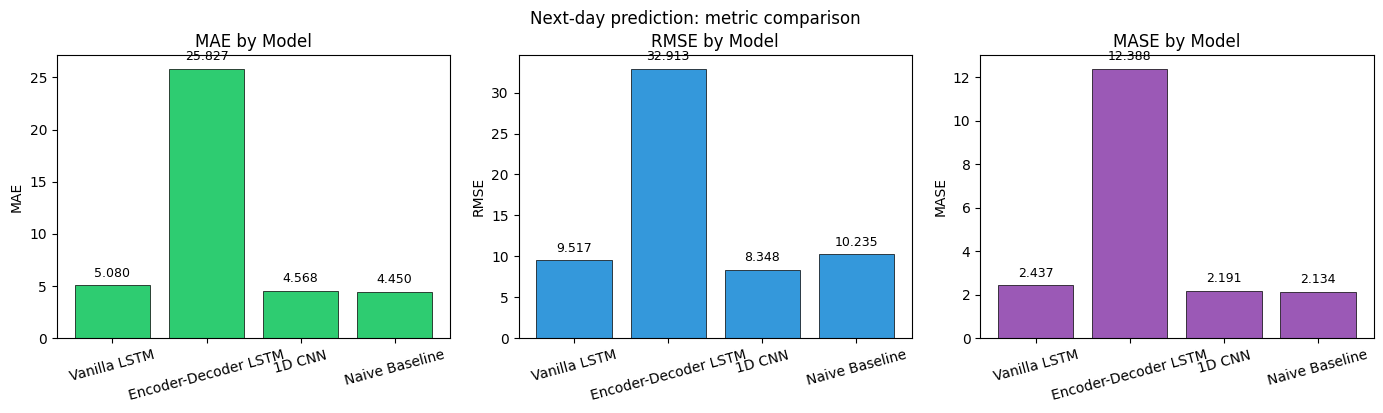

In [18]:
# 1. Bar charts: MAE, RMSE, MASE by model
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics = ['MAE', 'RMSE', 'MASE']
colors = ['#2ecc71', '#3498db', '#9b59b6']
for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric].values
    bars = ax.bar(results_df['Model'], vals, color=color, edgecolor='black', linewidth=0.5)
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.tick_params(axis='x', rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02 * max(vals), f'{v:.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.suptitle('Next-day prediction: metric comparison', y=1.02, fontsize=12)
plt.show()

Improvement over Naive Baseline (%):


,Model,MAE_imp_%,RMSE_imp_%,MASE_imp_%
0,Vanilla LSTM,-14.16,7.02,-14.16
1,Encoder-Decoder LSTM,-480.43,-221.58,-480.43
2,1D CNN,-2.66,18.44,-2.66


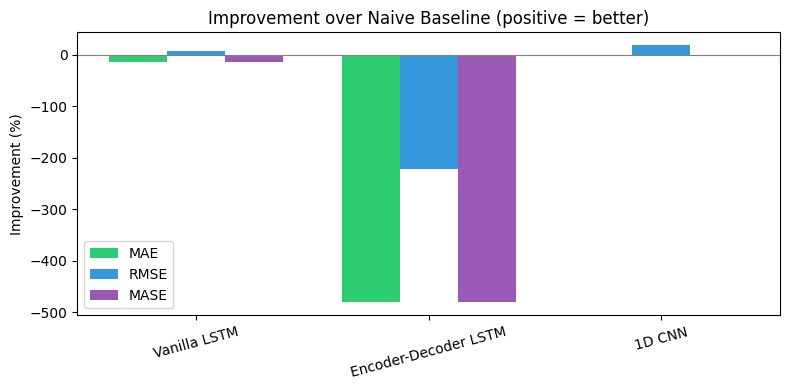

In [19]:
# 2. Improvement over Naive Baseline (%)
naive_mae = results_df[results_df['Model'] == 'Naive Baseline']['MAE'].values[0]
naive_rmse = results_df[results_df['Model'] == 'Naive Baseline']['RMSE'].values[0]
naive_mase = results_df[results_df['Model'] == 'Naive Baseline']['MASE'].values[0]
improvement = results_df[results_df['Model'] != 'Naive Baseline'].copy()
improvement['MAE_imp_%'] = (1 - improvement['MAE'] / naive_mae) * 100
improvement['RMSE_imp_%'] = (1 - improvement['RMSE'] / naive_rmse) * 100
improvement['MASE_imp_%'] = (1 - improvement['MASE'] / naive_mase) * 100
print('Improvement over Naive Baseline (%):')
display(improvement[['Model', 'MAE_imp_%', 'RMSE_imp_%', 'MASE_imp_%']].round(2))
fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(improvement))
w = 0.25
ax.bar(x - w, improvement['MAE_imp_%'], w, label='MAE', color='#2ecc71')
ax.bar(x, improvement['RMSE_imp_%'], w, label='RMSE', color='#3498db')
ax.bar(x + w, improvement['MASE_imp_%'], w, label='MASE', color='#9b59b6')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(improvement['Model'], rotation=15)
ax.set_ylabel('Improvement (%)')
ax.legend()
ax.set_title('Improvement over Naive Baseline (positive = better)')
plt.tight_layout()
plt.show()

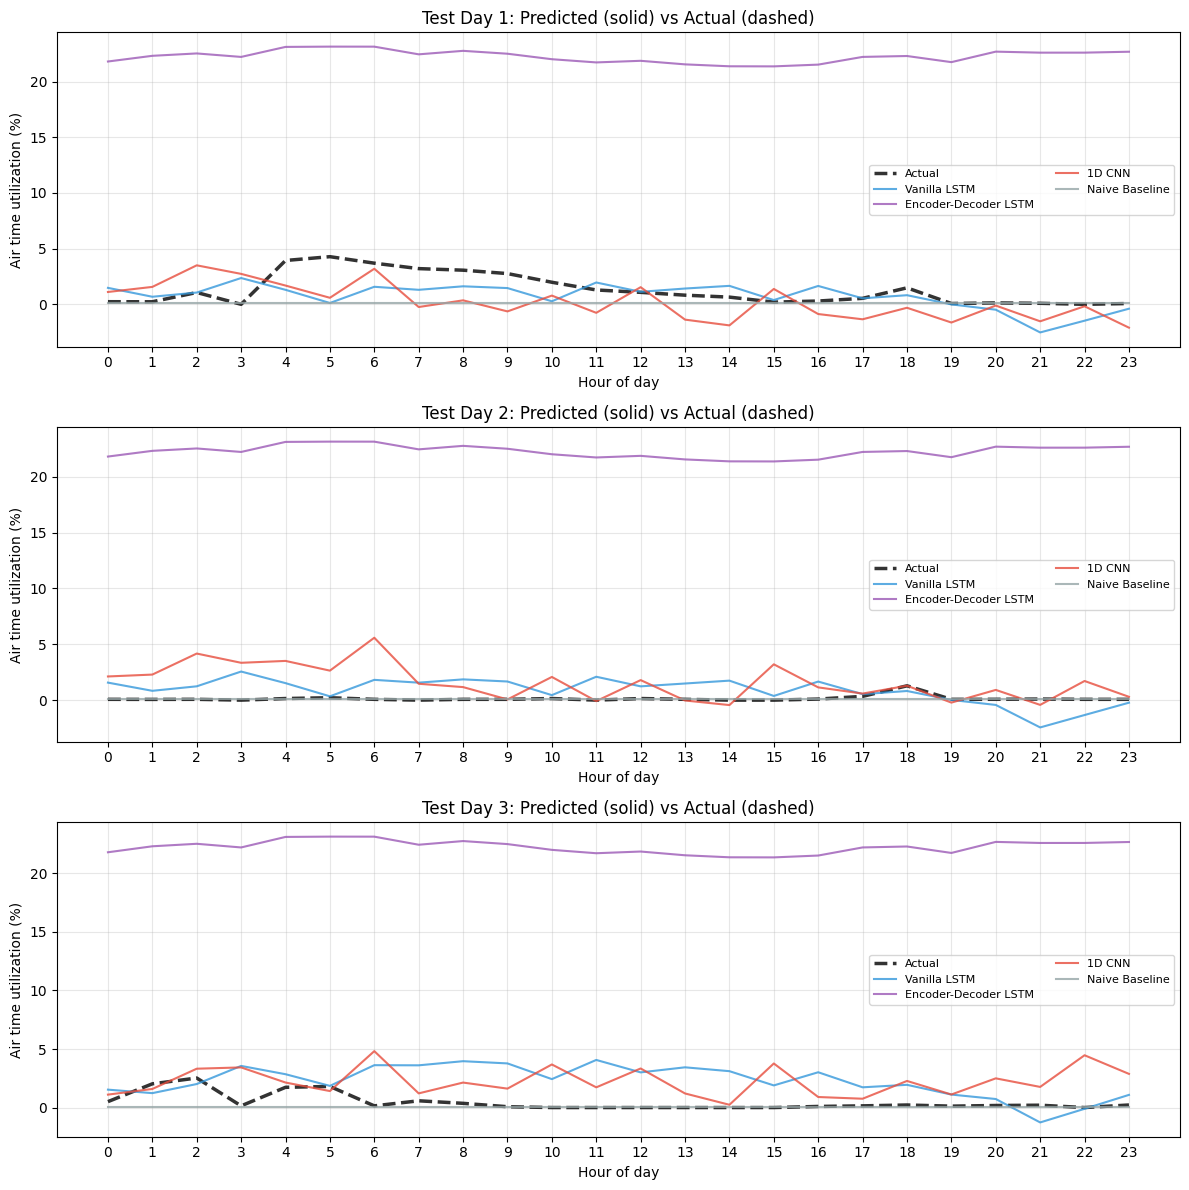

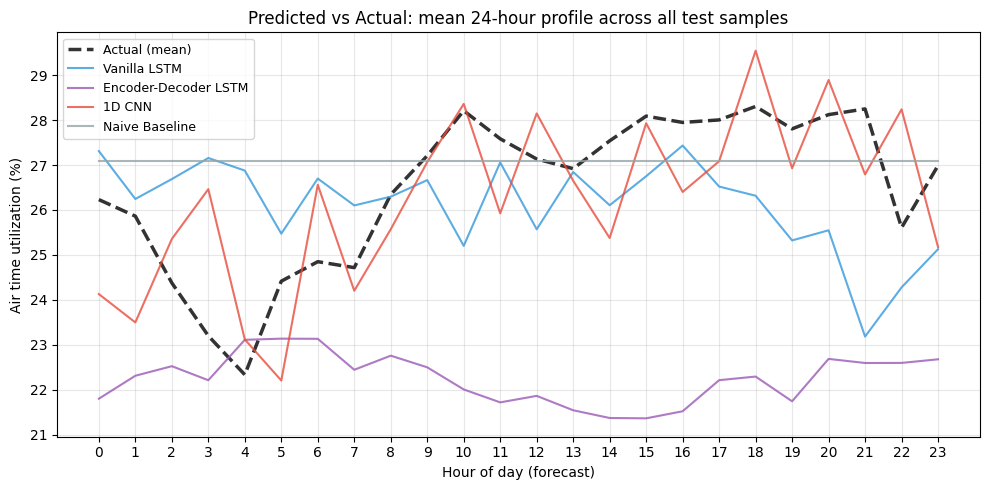

In [20]:
# 3. Predicted vs Actual: individual test days (actual as dashed line)
hours = np.arange(FORECAST_HORIZON)
n_test_days = len(y_test)  # Number of test samples (one per day)
n_show = min(3, n_test_days)  # Show up to 3 test days
fig, axes = plt.subplots(n_show, 1, figsize=(12, 4*n_show))
if n_show == 1:
    axes = [axes]
colors_pred = {'Vanilla LSTM': '#3498db', 'Encoder-Decoder LSTM': '#9b59b6', '1D CNN': '#e74c3c', 'Naive Baseline': '#95a5a6'}
for day_idx in range(n_show):
    ax = axes[day_idx]
    actual_day = y_test[day_idx]  # (24,)
    ax.plot(hours, actual_day, 'k--', linewidth=2.5, label='Actual', alpha=0.8)
    for name, y_pred in predictions.items():
        pred_day = y_pred[day_idx]
        ax.plot(hours, pred_day, '-', linewidth=1.5, label=name, color=colors_pred.get(name, None), alpha=0.8)
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Air time utilization (%)')
    ax.set_title(f'Test Day {day_idx+1}: Predicted (solid) vs Actual (dashed)')
    ax.legend(loc='best', fontsize=8, ncol=2)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(hours)
plt.tight_layout()
plt.show()

# 3b. Predicted vs Actual: average 24-hour profile over all test samples
actual_mean = y_test.mean(axis=0)  # (24,)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hours, actual_mean, 'k--', linewidth=2.5, label='Actual (mean)', alpha=0.8)
for name, y_pred in predictions.items():
    pred_mean = y_pred.mean(axis=0)
    ax.plot(hours, pred_mean, '-', linewidth=1.5, label=name, color=colors_pred.get(name, None), alpha=0.8)
ax.set_xlabel('Hour of day (forecast)')
ax.set_ylabel('Air time utilization (%)')
ax.set_title('Predicted vs Actual: mean 24-hour profile across all test samples')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(hours)
plt.tight_layout()
plt.show()

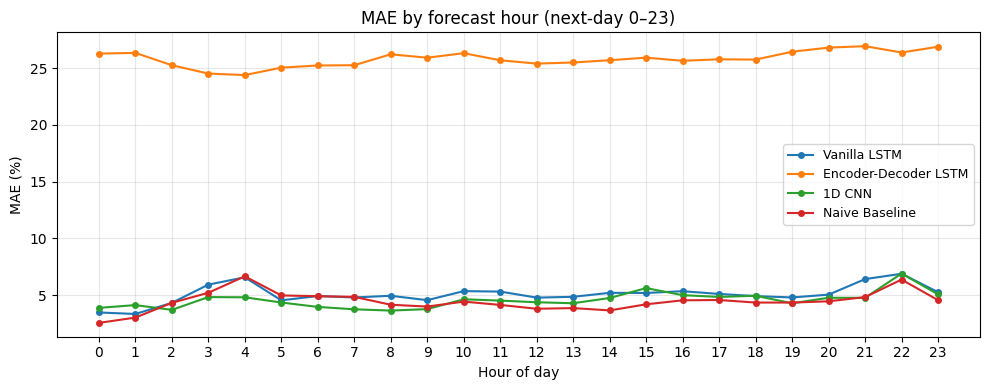

In [21]:
# 4. Per-hour-of-day MAE: which hour is hardest to predict?
fig, ax = plt.subplots(figsize=(10, 4))
for name, y_pred in predictions.items():
    mae_per_hour = np.abs(y_test - y_pred).mean(axis=0)  # (24,)
    ax.plot(hours, mae_per_hour, '-o', markersize=4, label=name)
ax.set_xlabel('Hour of day')
ax.set_ylabel('MAE (%)')
ax.set_title('MAE by forecast hour (next-day 0–23)')
ax.legend(loc='best', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(hours)
plt.tight_layout()
plt.show()

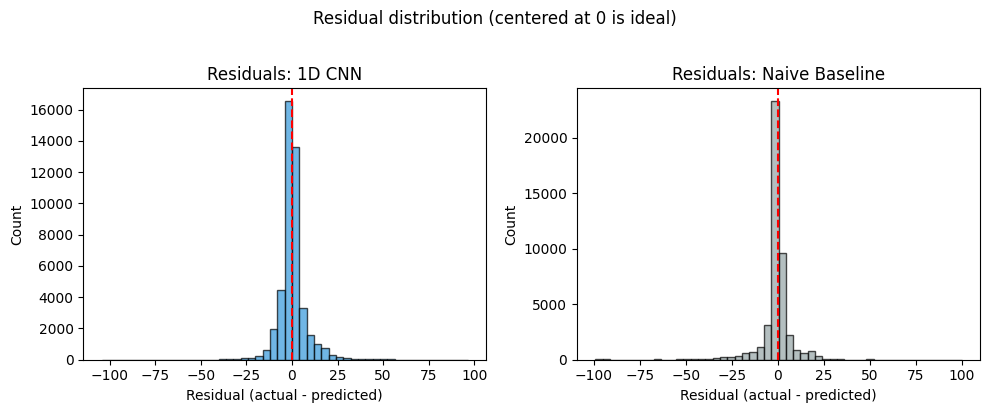

Residual mean (bias): 1D CNN = 0.2676, Naive = -0.5887
Residual std:         1D CNN = 8.3435, Naive = 10.2179


In [22]:
# 5. Residuals: distribution of (actual - predicted) for best DL model vs naive
dl_only = results_df[results_df['Model'] != 'Naive Baseline']
best_dl = dl_only.loc[dl_only['MAE'].idxmin(), 'Model']
y_best = predictions[best_dl]
residuals_best = (y_test - y_best).flatten()
residuals_naive = (y_test - y_pred_naive).flatten()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(residuals_best, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_xlabel('Residual (actual - predicted)')
axes[0].set_ylabel('Count')
axes[0].set_title(f'Residuals: {best_dl}')
axes[1].hist(residuals_naive, bins=50, color='#95a5a6', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (actual - predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residuals: Naive Baseline')
plt.suptitle('Residual distribution (centered at 0 is ideal)', y=1.02)
plt.tight_layout()
plt.show()
print(f'Residual mean (bias): {best_dl} = {residuals_best.mean():.4f}, Naive = {residuals_naive.mean():.4f}')
print(f'Residual std:         {best_dl} = {residuals_best.std():.4f}, Naive = {residuals_naive.std():.4f}')

### Key insights

- **Best model:** Check the results table and bar charts; the model with lowest MAE/RMSE/MASE is the best for next-day AU prediction.
- **Improvement over naive:** Positive % in the improvement plot means the DL model beats the naive (last-value) baseline.
- **Mean profile:** If predicted and actual mean profiles align, the model captures the typical daily pattern; gaps indicate systematic bias.
- **Per-hour MAE:** Peaks at certain hours suggest harder-to-predict periods (e.g. rush hours or quiet nights).
- **Residuals:** A symmetric, centered distribution indicates unbiased predictions; large spread means higher uncertainty.

In [23]:
# Print a one-line summary
best_row = results_df[results_df['Model'] == best_dl].iloc[0]
imp_mae = (1 - best_row['MAE'] / naive_mae) * 100
print(f'Best model: {best_dl} (MAE={best_row["MAE"]:.4f}, RMSE={best_row["RMSE"]:.4f}, MASE={best_row["MASE"]:.4f}).')
print(f'Improvement over Naive: MAE {imp_mae:+.1f}%.')

Best model: 1D CNN (MAE=4.5681, RMSE=8.3478, MASE=2.1911).
Improvement over Naive: MAE -2.7%.
